# Machine Learning project

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

## Part 1: Data Preprocessing

In [13]:
#Part1: Data Preprocessing

#task_mode: 
#"early" removes potential leakage semester-performance features;
#"full" keeps all features.
task_mode = "full"

df_raw = pd.read_csv("data/data.csv", sep=";")
df_raw.columns = df_raw.columns.str.strip()

#1.Missing values: add missing indicators + fill missing values
missing_cols = df_raw.columns[df_raw.isna().any()].tolist()
for col in missing_cols:
    df_raw[f"{col}_missing"] = df_raw[col].isna().astype(int)

num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols:
    if df_raw[col].isna().any():
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

for col in cat_cols:
    if df_raw[col].isna().any():
        mode_val = df_raw[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if not mode_val.empty else "Missing"
        df_raw[col] = df_raw[col].fillna(fill_val)

#2.Further processing
target_col = "Target"
X = df_raw.drop(columns=[target_col]).copy()
y = df_raw[target_col].copy()

#2.1 Leakage control for early-stage prediction
leakage_keywords = ["approved", "grade", "evaluations", "credited", "without evaluations"]
leakage_cols = [c for c in X.columns if any(k in c.lower() for k in leakage_keywords)]
if task_mode == "early":
    X = X.drop(columns=leakage_cols, errors="ignore")

#2.2 Treat coded categorical integers as categorical before one-hot
coded_categorical_cols = [
    "Marital status", "Application mode", "Application order", "Course",
    "Daytime/evening attendance", "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced",
    "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "International"
]
coded_categorical_cols = [c for c in coded_categorical_cols if c in X.columns]

for c in coded_categorical_cols:
    X[c] = X[c].astype("category")

#Keep boolean indicator for numeric binary columns not already converted
num_cols_X = X.select_dtypes(include=[np.number]).columns.tolist()
binary_numeric_cols = [
    c for c in num_cols_X if set(X[c].dropna().unique()).issubset({0, 1})
]
for c in binary_numeric_cols:
    X[c] = X[c].astype(bool)

#One-hot encode features and target (if target is non-numeric)
X_processed = pd.get_dummies(X, drop_first=False, dtype=int)
if not pd.api.types.is_numeric_dtype(y):
    y_processed = pd.get_dummies(y, prefix="Target", dtype=int)
else:
    y_processed = y

#2.3 Class-imbalance quick check
target_pct = y.value_counts(normalize=True) * 100

#2.4 Analyze if feature standardization is needed
num_cols_processed = X_processed.select_dtypes(include=[np.number]).columns.tolist()
binary_cols_processed = [
    c for c in num_cols_processed if set(X_processed[c].dropna().unique()).issubset({0, 1})
]
non_binary_cols_processed = [c for c in num_cols_processed if c not in binary_cols_processed]

if len(non_binary_cols_processed) > 1:
    stds = X_processed[non_binary_cols_processed].std(ddof=0)
    positive_stds = stds[stds > 0]
    if len(positive_stds) > 1:
        scale_ratio = positive_stds.max() / positive_stds.min()
    else:
        scale_ratio = 1.0
else:
    scale_ratio = 1.0

#Heuristic: if scale ratio is large, standardization is recommended
need_standardize = scale_ratio >= 10

X_standardized = X_processed.copy()
if non_binary_cols_processed:
    scaler = StandardScaler()
    X_standardized[non_binary_cols_processed] = scaler.fit_transform(
        X_standardized[non_binary_cols_processed]
    )

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns with missing values: {len(missing_cols)}")
print(f"task_mode: {task_mode} | removed leakage cols: {len(leakage_cols) if task_mode == 'early' else 0}")
print(f"Coded categorical cols used: {len(coded_categorical_cols)}")
print(f"Features before encoding: {X.shape}, after encoding: {X_processed.shape}")
print("Target distribution (%):")
print(target_pct.round(2))

print("\nStandardization Analysis: ")
print(f"Non-binary numeric features: {len(non_binary_cols_processed)}")
print(f"Scale ratio (max_std/min_std among non-binary features): {scale_ratio:.2f}")
print(f"Need standardization (heuristic >= 10): {need_standardize}")

Raw dataset shape: (4424, 37)
Columns with missing values: 0
task_mode: full | removed leakage cols: 0
Coded categorical cols used: 18
Features before encoding: (4424, 36), after encoding: (4424, 262)
Target distribution (%):
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

Standardization Analysis: 
Non-binary numeric features: 18
Scale ratio (max_std/min_std among non-binary features): 20.96
Need standardization (heuristic >= 10): True


## Part 2: Data Visualization (t-SNE)

Part2 Objective: Use t-SNE for high-dimensional projection and provide visual insights.
Current task_mode from Part1: full
Samples used for visualization: 3000
Chosen scaling strategy: Scale non-binary only (X_standardized)

EDA: Target distribution


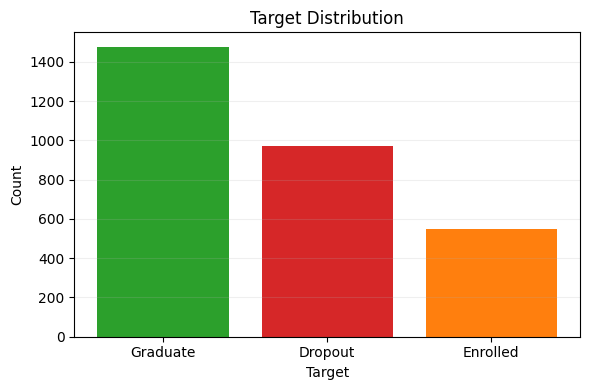

EDA: Correlation heatmap (top numeric features by variance)


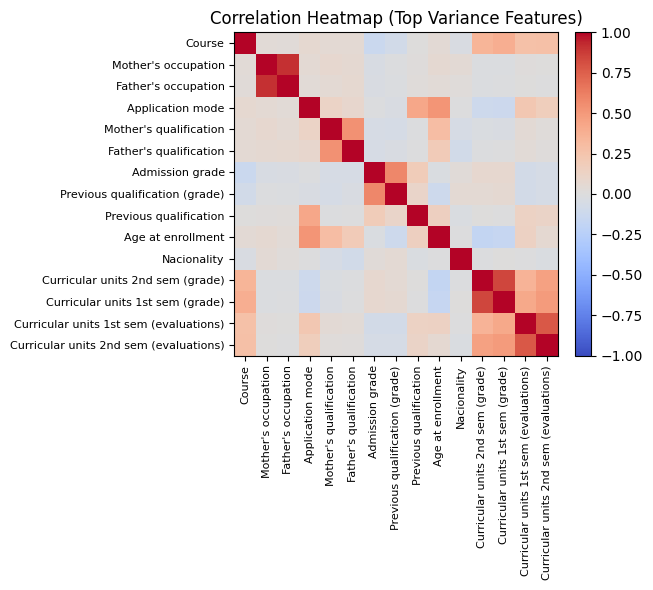


Perplexity search results:
 perplexity  silhouette
         50      0.0248
         40      0.0232
         30      0.0139
Selected perplexity: 50 | Best t-SNE silhouette: 0.0248


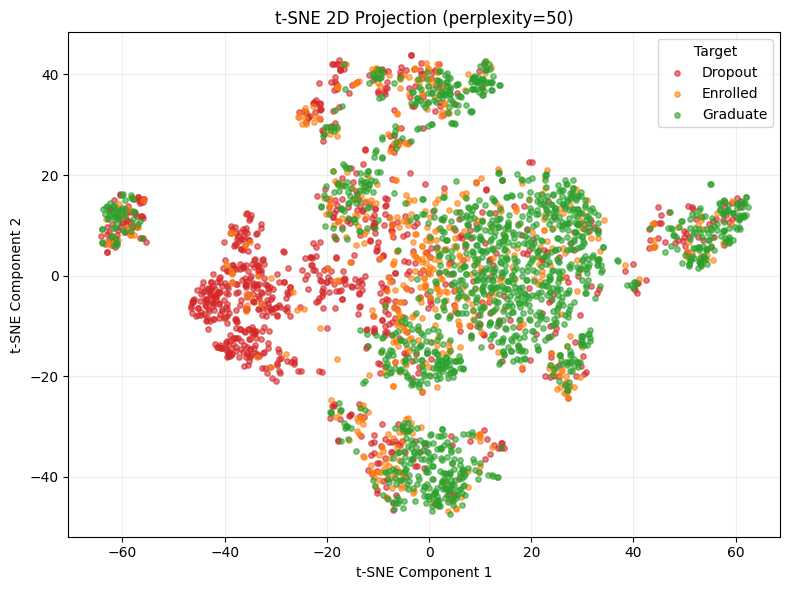

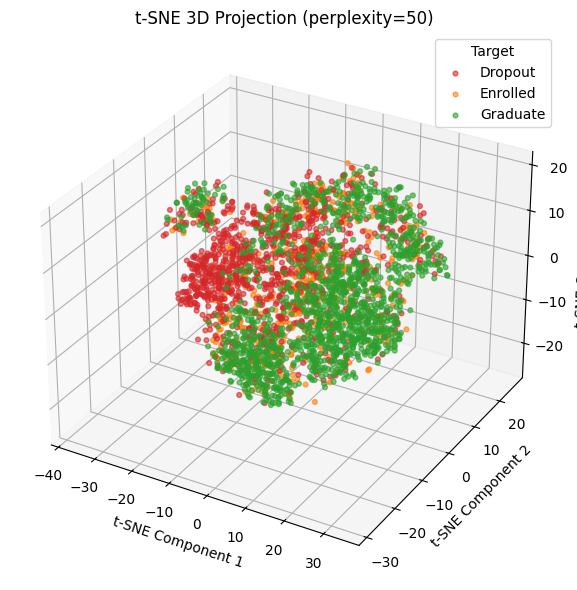

In [14]:
#Part2: Data Visualization (t-SNE core + EDA)

print("Part2 Objective: Use t-SNE for high-dimensional projection and provide visual insights.")
print(f"Current task_mode from Part1: {task_mode}")

#1.Prepare features and labels
X_base = X_processed.copy()
y_label = y.copy() if isinstance(y, pd.Series) else pd.Series(y, name="Target")

le = LabelEncoder()
y_encoded = le.fit_transform(y_label)
class_names = list(le.classes_)

#Optional sampling for speed and clearer scatter plots
max_points = 3000
if len(X_base) > max_points:
    sample_idx = X_base.sample(n=max_points, random_state=42).index
    X_base = X_base.loc[sample_idx]
    y_label = y_label.loc[sample_idx]
    y_encoded = le.transform(y_label)

#Keep feature variants for Part3 compatibility
X_no_scale = X_base.copy()

if "X_standardized" in globals():
    X_selective_scaled = X_standardized.loc[X_base.index].copy()
else:
    #Fallback: standardize only non-binary columns
    X_selective_scaled = X_base.copy()
    num_cols_base = X_selective_scaled.select_dtypes(include=[np.number]).columns.tolist()
    binary_cols_base = [
        c for c in num_cols_base if set(X_selective_scaled[c].dropna().unique()).issubset({0, 1})
    ]
    non_binary_cols_base = [c for c in num_cols_base if c not in binary_cols_base]
    if non_binary_cols_base:
        scaler_fallback = StandardScaler()
        X_selective_scaled[non_binary_cols_base] = scaler_fallback.fit_transform(
            X_selective_scaled[non_binary_cols_base]
        )

best_strategy = "Scale non-binary only (X_standardized)" if "X_standardized" in globals() else "No scaling (X_processed)"
X_scaled_df = X_selective_scaled if best_strategy.startswith("Scale") else X_no_scale
X_scaled = X_scaled_df.values

print(f"Samples used for visualization: {len(X_scaled_df)}")
print(f"Chosen scaling strategy: {best_strategy}")

#2.EDA add-ons: Target distribution + correlation heatmap
print("\nEDA: Target distribution")
target_counts = y_label.value_counts()
plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values, color=["#2ca02c", "#d62728", "#ff7f0e"][:len(target_counts)])
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("EDA: Correlation heatmap (top numeric features by variance)")
num_cols_raw = df_raw.drop(columns=[target_col], errors="ignore").select_dtypes(include=[np.number]).columns.tolist()
if num_cols_raw:
    var_series = df_raw[num_cols_raw].var().sort_values(ascending=False)
    top_k = min(15, len(var_series))
    top_corr_cols = var_series.head(top_k).index
    corr = df_raw[top_corr_cols].corr()

    plt.figure(figsize=(7, 6))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(top_corr_cols)), top_corr_cols, rotation=90, fontsize=8)
    plt.yticks(range(len(top_corr_cols)), top_corr_cols, fontsize=8)
    plt.title("Correlation Heatmap (Top Variance Features)")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found for correlation heatmap.")

#3.t-SNE 2D: try multiple perplexities
perplexities = [30, 40, 50]
perplexities = [p for p in perplexities if p < len(X_scaled_df)]
if not perplexities:
    fallback = max(5, min(30, len(X_scaled_df) // 3))
    perplexities = [p for p in [fallback] if p < len(X_scaled_df)]

perp_scores = []
best_perp = None
best_tsne_sil = -np.inf
best_tsne_2d = None

for p in perplexities:
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    emb_2d = tsne.fit_transform(X_scaled)
    sil = silhouette_score(emb_2d, y_encoded)
    perp_scores.append({"perplexity": p, "silhouette": float(sil)})
    if sil > best_tsne_sil:
        best_tsne_sil = sil
        best_perp = p
        best_tsne_2d = emb_2d

perp_df = pd.DataFrame(perp_scores).sort_values("silhouette", ascending=False).reset_index(drop=True)
print("\nPerplexity search results:")
print(perp_df.round(4).to_string(index=False))
print(f"Selected perplexity: {best_perp} | Best t-SNE silhouette: {best_tsne_sil:.4f}")

#Build a dataframe for downstream analysis/plotting
tsne_df = pd.DataFrame(best_tsne_2d, columns=["TSNE1", "TSNE2"])
tsne_df["Target"] = y_label.values

#2D scatter plot
color_map = {"Dropout": "#d62728", "Graduate": "#2ca02c", "Enrolled": "#ff7f0e"}
plt.figure(figsize=(8, 6))
for cls in class_names:
    mask = (y_label.values == cls)
    plt.scatter(
        best_tsne_2d[mask, 0],
        best_tsne_2d[mask, 1],
        s=15,
        alpha=0.6,
        label=str(cls),
        color=color_map.get(str(cls), None)
    )
plt.title(f"t-SNE 2D Projection (perplexity={best_perp})")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Target")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#4.3D t-SNE
enable_3d = True
if enable_3d:
    tsne_3d = TSNE(
        n_components=3,
        perplexity=best_perp,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    emb_tsne_3d = tsne_3d.fit_transform(X_scaled)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    for cls in class_names:
        mask = (y_label.values == cls)
        ax.scatter(
            emb_tsne_3d[mask, 0],
            emb_tsne_3d[mask, 1],
            emb_tsne_3d[mask, 2],
            s=12,
            alpha=0.6,
            label=str(cls),
            color=color_map.get(str(cls), None)
        )
    ax.set_title(f"t-SNE 3D Projection (perplexity={best_perp})")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.set_zlabel("t-SNE Component 3")
    ax.legend(title="Target")
    plt.tight_layout()
    plt.show()

### 2.1 Findings & Insights
1. **Class Imbalance:** Graduate is the largest class, Dropout is second, and Enrolled is the smallest, indicating an imbalanced target distribution.
2. **Cluster Separation:** In the t-SNE 2D plot, Graduate and Dropout form their own clusters, but the middle region shows notable overlap.
3. **The "Enrolled" Class:** Enrolled points mostly sit between the other two classes, matching the transitional nature of currently enrolled students.
4. **Implications for Modeling:** The overlap suggests a non-linear decision boundary, favoring models like Random Forest, Gradient Boosting, or MLP.
5. **3D t-SNE:** The 3D view looks more coherent but still shows mixing, further supporting a non-linear structure.

## Part 3: Clustering Analysis

Part3 Objective: Compare clustering algorithms and select the best result.
Algorithms: K-Means (centroid-based), Agglomerative Ward (hierarchical), DBSCAN (density-based, robust to noise).
DBSCAN setting: run after PCA reduction to 20-50 dimensions.
Feature source: From Part2 best strategy: Scale non-binary only (X_standardized)
Clustering matrix shape: (3000, 262)
DBSCAN PCA dimensions used: [20, 30, 40, 50]
K-Means/Agglomerative feature spaces: ['raw', 'pca=20', 'pca=30']
Scoring mode: interpretability_favored

Part3 Evaluation Table (top 12, optimized weighted score):
           algorithm      config   k  pca_dim  eps  min_samples  n_clusters_found  noise_ratio  valid_internal  silhouette  calinski_harabasz  davies_bouldin  internal_score  external_score  cluster_count_eff  cluster_count_penalty  largest_cluster_ratio  structure_penalty  noise_penalty  missing_internal_penalty  final_score  overall_rank    inertia  ARI_ref  NMI_ref
             K-Means pca=20, k=5 5.0     20.0  NaN 

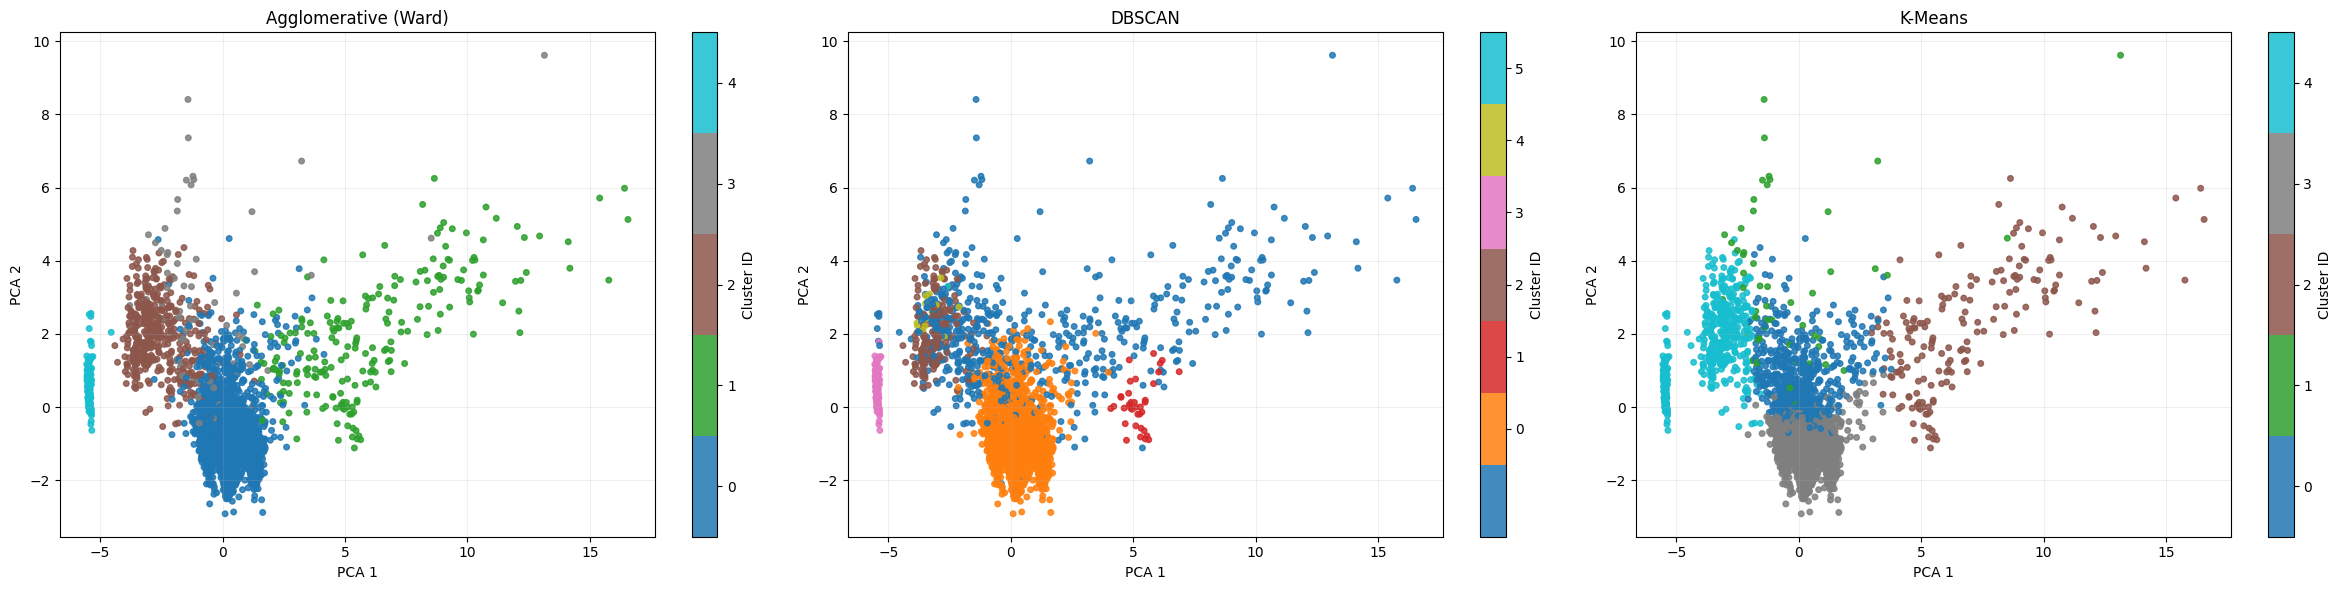

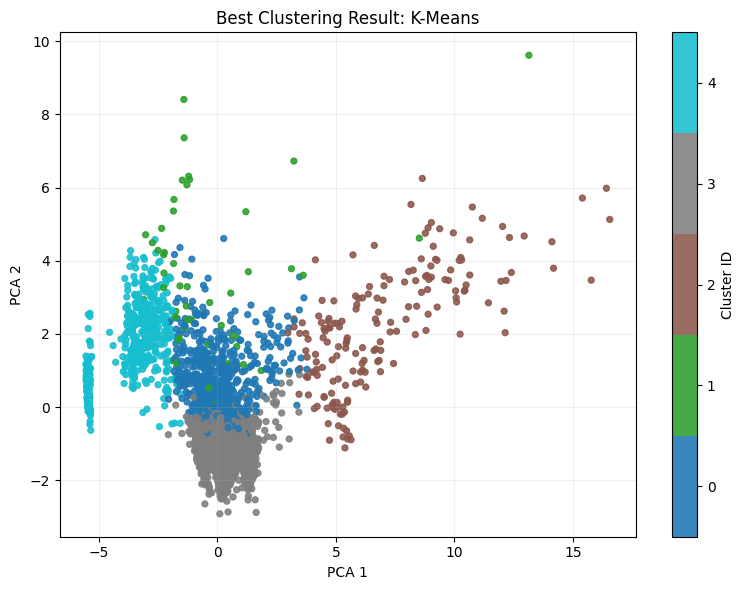


Part3 Conclusion:
Best algorithm: K-Means
Best number of clusters (k): 5
Best feature space for this algorithm: PCA 20 dims
Reason: highest optimized weighted score (internal + external + structure/noise penalties, interpretability-favored).
Interpretation tips:
- Higher Silhouette and CH suggest better separated and compact clusters.
- Lower Davies-Bouldin indicates tighter, more distinct clusters.
- DBSCAN now runs on PCA-reduced space (20-50 dimensions) before clustering.
- DBSCAN can detect noise points (label = -1), useful for outlier-aware clustering.
- ARI/NMI are shown as reference against known target labels (external validation only).


In [22]:
# Part3: Clustering Analysis
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
 )

print("Part3 Objective: Compare clustering algorithms and select the best result.")
print("Algorithms: K-Means (centroid-based), Agglomerative Ward (hierarchical), DBSCAN (density-based, robust to noise).")
print("DBSCAN setting: run after PCA reduction to 20-50 dimensions.")

# 1) Choose feature matrix from previous parts
if "best_strategy" in globals() and "X_no_scale" in globals() and "X_selective_scaled" in globals():
    if best_strategy == "Scale non-binary only (X_standardized)":
        X_cluster_df = X_selective_scaled.copy()
    else:
        X_cluster_df = X_no_scale.copy()
    feature_source = f"From Part2 best strategy: {best_strategy}"
elif "X_standardized" in globals() and "need_standardize" in globals():
    X_cluster_df = X_standardized.copy() if need_standardize else X_processed.copy()
    feature_source = "From Part1 heuristic choice (need_standardize)."
elif "X_standardized" in globals():
    X_cluster_df = X_standardized.copy()
    feature_source = "From Part1 standardized features."
else:
    X_cluster_df = X_processed.copy()
    feature_source = "From Part1 one-hot processed features (no scaling)."

# Keep numeric columns only
X_cluster_df = X_cluster_df.select_dtypes(include=[np.number]).copy()

# Optional reference labels for external validation (not used for model training)
y_ref = None
if "y" in globals():
    y_ref = pd.Series(y).reindex(X_cluster_df.index)
elif "y_label" in globals():
    y_ref = pd.Series(y_label).reindex(X_cluster_df.index)

# Optional sampling for speed
max_cluster_points = 3000
if len(X_cluster_df) > max_cluster_points:
    sample_idx = X_cluster_df.sample(n=max_cluster_points, random_state=42).index
    X_cluster_df = X_cluster_df.loc[sample_idx]
    if y_ref is not None:
        y_ref = y_ref.loc[sample_idx]
    print(f"Sampling applied for clustering: {max_cluster_points} points used.")

X_cluster = X_cluster_df.values
print(f"Feature source: {feature_source}")
print(f"Clustering matrix shape: {X_cluster.shape}")

# 2) Train algorithms and evaluate
k_range = list(range(2, 9))
dbscan_eps_candidates = [3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
dbscan_min_samples_candidates = [3, 4, 5, 10, 15]

# DBSCAN will be tested on PCA-reduced spaces
dbscan_pca_dims_raw = [20, 30, 40, 50]
max_dbscan_dim = min(50, X_cluster.shape[1], X_cluster.shape[0] - 1)
if max_dbscan_dim < 2:
    raise ValueError("Not enough dimensions/samples to run PCA before DBSCAN.")
dbscan_pca_dims = [d for d in dbscan_pca_dims_raw if d <= max_dbscan_dim]
if not dbscan_pca_dims:
    dbscan_pca_dims = [max_dbscan_dim]
print(f"DBSCAN PCA dimensions used: {dbscan_pca_dims}")

# Precompute PCA-transformed feature spaces for DBSCAN
dbscan_spaces = {}
for pca_dim in dbscan_pca_dims:
    pca_dbscan = PCA(n_components=pca_dim, random_state=42)
    dbscan_spaces[pca_dim] = pca_dbscan.fit_transform(X_cluster)

# Strengthen K-Means and Agglomerative by searching in multiple feature spaces
kagg_pca_dims = [d for d in dbscan_pca_dims if d <= 30]
if not kagg_pca_dims:
    kagg_pca_dims = [dbscan_pca_dims[0]]
kagg_spaces = {"raw": X_cluster}
for pca_dim in kagg_pca_dims:
    kagg_spaces[f"pca={pca_dim}"] = dbscan_spaces[pca_dim]
print(f"K-Means/Agglomerative feature spaces: {list(kagg_spaces.keys())}")

results = []
labels_store = {}

def safe_external_scores(y_reference, pred_labels, valid_mask):
    """Compute ARI/NMI safely on filtered points."""
    if y_reference is None:
        return np.nan, np.nan
    valid_y = y_reference.notna().values
    use = valid_mask & valid_y
    if use.sum() <= 1:
        return np.nan, np.nan
    y_valid = y_reference[use].astype(str).values
    pred_valid = pred_labels[use]
    return adjusted_rand_score(y_valid, pred_valid), normalized_mutual_info_score(y_valid, pred_valid)

# K-Means + Agglomerative search across raw/PCA feature spaces
for space_name, X_kagg in kagg_spaces.items():
    pca_dim_val = np.nan if space_name == "raw" else int(space_name.split("=")[1])

    for k in k_range:
        # K-Means
        km = KMeans(n_clusters=k, n_init=50, random_state=42)
        labels_km = km.fit_predict(X_kagg)
        valid_mask_km = np.ones(len(labels_km), dtype=bool)

        sil_km = silhouette_score(X_kagg, labels_km)
        ch_km = calinski_harabasz_score(X_kagg, labels_km)
        db_km = davies_bouldin_score(X_kagg, labels_km)
        ari_km, nmi_km = safe_external_scores(y_ref, labels_km, valid_mask_km)

        config_km = f"k={k}" if space_name == "raw" else f"{space_name}, k={k}"
        results.append({
            "algorithm": "K-Means",
            "config": config_km,
            "k": k,
            "pca_dim": pca_dim_val,
            "eps": np.nan,
            "min_samples": np.nan,
            "n_clusters_found": len(np.unique(labels_km)),
            "noise_ratio": 0.0,
            "silhouette": sil_km,
            "calinski_harabasz": ch_km,
            "davies_bouldin": db_km,
            "inertia": km.inertia_,
            "ARI_ref": ari_km,
            "NMI_ref": nmi_km
        })
        labels_store[("K-Means", config_km)] = labels_km

        # Agglomerative Clustering (Ward linkage)
        agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels_agg = agg.fit_predict(X_kagg)
        valid_mask_agg = np.ones(len(labels_agg), dtype=bool)

        sil_agg = silhouette_score(X_kagg, labels_agg)
        ch_agg = calinski_harabasz_score(X_kagg, labels_agg)
        db_agg = davies_bouldin_score(X_kagg, labels_agg)
        ari_agg, nmi_agg = safe_external_scores(y_ref, labels_agg, valid_mask_agg)

        config_agg = f"k={k}" if space_name == "raw" else f"{space_name}, k={k}"
        results.append({
            "algorithm": "Agglomerative (Ward)",
            "config": config_agg,
            "k": k,
            "pca_dim": pca_dim_val,
            "eps": np.nan,
            "min_samples": np.nan,
            "n_clusters_found": len(np.unique(labels_agg)),
            "noise_ratio": 0.0,
            "silhouette": sil_agg,
            "calinski_harabasz": ch_agg,
            "davies_bouldin": db_agg,
            "inertia": np.nan,
            "ARI_ref": ari_agg,
            "NMI_ref": nmi_agg
        })
        labels_store[("Agglomerative (Ward)", config_agg)] = labels_agg

# DBSCAN parameter search on PCA-reduced spaces
for pca_dim, X_dbscan in dbscan_spaces.items():
    for eps in dbscan_eps_candidates:
        for min_samples in dbscan_min_samples_candidates:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels_dbscan = dbscan.fit_predict(X_dbscan)

            non_noise_mask = labels_dbscan != -1
            unique_non_noise = np.unique(labels_dbscan[non_noise_mask]) if non_noise_mask.any() else np.array([])
            n_clusters_found = len(unique_non_noise)
            noise_ratio = float((labels_dbscan == -1).mean())

            # Internal metrics need at least 2 clusters on evaluated points
            if n_clusters_found >= 2 and non_noise_mask.sum() > n_clusters_found:
                X_eval = X_dbscan[non_noise_mask]
                y_eval = labels_dbscan[non_noise_mask]
                sil_dbscan = silhouette_score(X_eval, y_eval)
                ch_dbscan = calinski_harabasz_score(X_eval, y_eval)
                db_dbscan = davies_bouldin_score(X_eval, y_eval)
                valid_mask_dbscan = non_noise_mask.copy()
            else:
                sil_dbscan = np.nan
                ch_dbscan = np.nan
                db_dbscan = np.nan
                valid_mask_dbscan = np.zeros(len(labels_dbscan), dtype=bool)

            ari_dbscan, nmi_dbscan = safe_external_scores(y_ref, labels_dbscan, valid_mask_dbscan)

            config_name = f"pca={pca_dim}, eps={eps}, min_samples={min_samples}"
            results.append({
                "algorithm": "DBSCAN",
                "config": config_name,
                "k": np.nan,
                "pca_dim": pca_dim,
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters_found": n_clusters_found,
                "noise_ratio": noise_ratio,
                "silhouette": sil_dbscan,
                "calinski_harabasz": ch_dbscan,
                "davies_bouldin": db_dbscan,
                "inertia": np.nan,
                "ARI_ref": ari_dbscan,
                "NMI_ref": nmi_dbscan
            })
            labels_store[("DBSCAN", config_name)] = labels_dbscan

results_df = pd.DataFrame(results)

# 3) Optimized weighted scoring (interpretability-favored)
rank_base = results_df.copy()
rank_base["valid_internal"] = rank_base[["silhouette", "calinski_harabasz", "davies_bouldin"]].notna().all(axis=1)
if not rank_base["valid_internal"].any():
    raise ValueError("No valid clustering result for internal metrics. Please widen DBSCAN parameter range.")

scoring_mode = "interpretability_favored"
print(f"Scoring mode: {scoring_mode}")

def minmax_norm(series):
    s_min = series.min()
    s_max = series.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)

# Normalize internal metrics to [0, 1] for fair combination
# For missing internal metrics, use conservative fill so they can still be ranked
sil_for_norm = rank_base["silhouette"].fillna(rank_base.loc[rank_base["valid_internal"], "silhouette"].min())
ch_for_norm = rank_base["calinski_harabasz"].fillna(rank_base.loc[rank_base["valid_internal"], "calinski_harabasz"].min())
db_for_norm = rank_base["davies_bouldin"].fillna(rank_base.loc[rank_base["valid_internal"], "davies_bouldin"].max())
rank_base["sil_norm"] = minmax_norm(sil_for_norm)
rank_base["ch_norm"] = minmax_norm(np.log1p(ch_for_norm))
rank_base["db_norm"] = 1 - minmax_norm(db_for_norm)
rank_base["internal_score"] = (
    0.25 * rank_base["sil_norm"] +
    0.50 * rank_base["ch_norm"] +
    0.25 * rank_base["db_norm"]
)

# Optional external reference score (kept low weight)
has_external = (
    (not rank_base["ARI_ref"].isna().all()) and
    (not rank_base["NMI_ref"].isna().all())
)
if has_external:
    rank_base["ari_norm"] = minmax_norm(rank_base["ARI_ref"].fillna(rank_base["ARI_ref"].min()))
    rank_base["nmi_norm"] = minmax_norm(rank_base["NMI_ref"].fillna(rank_base["NMI_ref"].min()))
    rank_base["external_score"] = 0.5 * rank_base["ari_norm"] + 0.5 * rank_base["nmi_norm"]
else:
    rank_base["external_score"] = 0.0

# Penalize high-noise settings
rank_base["noise_penalty"] = rank_base["noise_ratio"].clip(lower=0.0, upper=1.0)
# Penalize missing internal metrics so those settings participate but rank lower
rank_base["missing_internal_penalty"] = (~rank_base["valid_internal"]).astype(float)

# Structure-aware penalty: penalize too few/too many clusters and highly dominant single cluster
def structure_stats(row):
    labels = labels_store[(row["algorithm"], row["config"])]
    non_noise = labels != -1
    if non_noise.sum() == 0:
        return pd.Series({
            "cluster_count_eff": 0.0,
            "cluster_count_penalty": 1.0,
            "largest_cluster_ratio": 1.0,
            "structure_penalty": 1.0
        })

    unique_labels, counts = np.unique(labels[non_noise], return_counts=True)
    cluster_count_eff = float(len(unique_labels))
    largest_cluster_ratio = float(counts.max() / counts.sum())

    # Prefer moderate cluster counts (3 to 5); penalize both too few and too many clusters
    few_cluster_penalty = max(0.0, (3.0 - cluster_count_eff) / 2.0)
    many_cluster_penalty = max(0.0, (cluster_count_eff - 5.0) / 3.0)
    cluster_count_penalty = min(1.0, few_cluster_penalty + many_cluster_penalty)
    # Penalize when one cluster dominates too much
    dominance_penalty = max(0.0, (largest_cluster_ratio - 0.70) / 0.30)
    structure_penalty = min(1.0, 0.6 * cluster_count_penalty + 0.4 * dominance_penalty)

    return pd.Series({
        "cluster_count_eff": cluster_count_eff,
        "cluster_count_penalty": cluster_count_penalty,
        "largest_cluster_ratio": largest_cluster_ratio,
        "structure_penalty": structure_penalty
    })

rank_base[["cluster_count_eff", "cluster_count_penalty", "largest_cluster_ratio", "structure_penalty"]] = rank_base.apply(structure_stats, axis=1)

if scoring_mode == "interpretability_favored":
    if has_external:
        rank_base["final_score"] = (
            0.50 * rank_base["internal_score"] +
            0.35 * rank_base["external_score"] -
            0.05 * rank_base["noise_penalty"] -
            0.10 * rank_base["structure_penalty"] -
            0.30 * rank_base["missing_internal_penalty"]
        )
    else:
        rank_base["final_score"] = (
            0.80 * rank_base["internal_score"] -
            0.08 * rank_base["noise_penalty"] -
            0.12 * rank_base["structure_penalty"] -
            0.30 * rank_base["missing_internal_penalty"]
        )
else:
    if has_external:
        rank_base["final_score"] = (
            0.75 * rank_base["internal_score"] +
            0.15 * rank_base["external_score"] -
            0.10 * rank_base["noise_penalty"] -
            0.30 * rank_base["missing_internal_penalty"]
        )
    else:
        rank_base["final_score"] = (
            0.90 * rank_base["internal_score"] -
            0.10 * rank_base["noise_penalty"] -
            0.30 * rank_base["missing_internal_penalty"]
        )

rank_base["overall_rank"] = rank_base["final_score"].rank(ascending=False, method="min")
ranked_df = rank_base.sort_values(
    by=["final_score", "internal_score", "silhouette"],
    ascending=[False, False, False]
).reset_index(drop=True)

best_row = ranked_df.iloc[0]
best_algo = best_row["algorithm"]
best_config = best_row["config"]
best_k = int(best_row["k"]) if pd.notna(best_row["k"]) else None
best_labels = labels_store[(best_algo, best_config)]

print("\nPart3 Evaluation Table (top 12, optimized weighted score):")
display_cols = [
    "algorithm", "config", "k", "pca_dim", "eps", "min_samples", "n_clusters_found", "noise_ratio",
    "valid_internal", "silhouette", "calinski_harabasz", "davies_bouldin", "internal_score", "external_score",
    "cluster_count_eff", "cluster_count_penalty", "largest_cluster_ratio", "structure_penalty", "noise_penalty",
    "missing_internal_penalty", "final_score", "overall_rank", "inertia", "ARI_ref", "NMI_ref"
]
print(ranked_df[display_cols].head(12).round(4).to_string(index=False))

invalid_dbscan_count = (
    results_df[(results_df["algorithm"] == "DBSCAN") & results_df["silhouette"].isna()]
    .shape[0]
 )
if invalid_dbscan_count > 0:
    print(f"\nNote: {invalid_dbscan_count} DBSCAN settings lacked full internal metrics but were included with missing-metric penalty.")

# 4) Visualize clusters in 2D using PCA projection
pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X_cluster)

best_per_algo = (
    ranked_df.sort_values(["algorithm", "final_score", "silhouette"], ascending=[True, False, False])
    .groupby("algorithm", as_index=False)
    .first()
)

algo_order = best_per_algo["algorithm"].tolist()
fig, axes = plt.subplots(1, len(algo_order), figsize=(8 * len(algo_order), 6))
if len(algo_order) == 1:
    axes = [axes]

def plot_with_discrete_cluster_ids(ax_obj, x_2d, labels, point_size=16, alpha=0.85):
    unique_ids = np.sort(np.unique(labels))
    id_to_pos = {cid: i for i, cid in enumerate(unique_ids)}
    mapped = np.array([id_to_pos[cid] for cid in labels])

    cmap = plt.get_cmap("tab10", len(unique_ids))
    sc_local = ax_obj.scatter(
        x_2d[:, 0], x_2d[:, 1],
        c=mapped, cmap=cmap, s=point_size, alpha=alpha,
        vmin=-0.5, vmax=len(unique_ids) - 0.5
    )

    # Show only real cluster IDs on colorbar; DBSCAN noise label -1 is excluded
    display_ids = [cid for cid in unique_ids if cid != -1]
    if not display_ids:
        display_ids = list(unique_ids)

    display_ticks = [id_to_pos[cid] for cid in display_ids]
    cbar = plt.colorbar(sc_local, ax=ax_obj, ticks=display_ticks)
    cbar.set_ticklabels([str(int(cid)) for cid in display_ids])
    cbar.set_label("Cluster ID")

    return sc_local

for ax, algo_name in zip(axes, algo_order):
    row_algo = best_per_algo[best_per_algo["algorithm"] == algo_name].iloc[0]
    config_algo = row_algo["config"]
    labels_algo = labels_store[(algo_name, config_algo)]

    plot_with_discrete_cluster_ids(ax, X_vis, labels_algo, point_size=16, alpha=0.85)

    ax.set_title(f"{algo_name}")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Best model visualization
fig_best, ax_best = plt.subplots(figsize=(8, 6))
plot_with_discrete_cluster_ids(ax_best, X_vis, best_labels, point_size=18, alpha=0.88)

ax_best.set_title(f"Best Clustering Result: {best_algo}")
ax_best.set_xlabel("PCA 1")
ax_best.set_ylabel("PCA 2")
ax_best.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 5) Final conclusion
print("\nPart3 Conclusion:")
print(f"Best algorithm: {best_algo}")
if best_algo == "DBSCAN":
    print(f"Best DBSCAN setting: {best_config}")
    print(f"Clusters found (excluding noise): {int(best_row['n_clusters_found'])}")
    print(f"Noise ratio: {best_row['noise_ratio']:.2%}")
else:
    print(f"Best number of clusters (k): {best_k}")
    if pd.notna(best_row["pca_dim"]):
        print(f"Best feature space for this algorithm: PCA {int(best_row['pca_dim'])} dims")
    else:
        print("Best feature space for this algorithm: raw features")
print("Reason: highest optimized weighted score (internal + external + structure/noise penalties, interpretability-favored).")
print("Interpretation tips:")
print("- Higher Silhouette and CH suggest better separated and compact clusters.")
print("- Lower Davies-Bouldin indicates tighter, more distinct clusters.")
print("- DBSCAN now runs on PCA-reduced space (20-50 dimensions) before clustering.")
print("- DBSCAN can detect noise points (label = -1), useful for outlier-aware clustering.")
if not ranked_df["ARI_ref"].isna().all():
    print("- ARI/NMI are shown as reference against known target labels (external validation only).")

In [21]:
# Quick summary of ranking result
summary_cols = [
    "algorithm", "config", "k", "pca_dim", "n_clusters_found", "noise_ratio",
    "valid_internal", "silhouette", "calinski_harabasz", "davies_bouldin",
    "internal_score", "external_score", "structure_penalty",
    "missing_internal_penalty", "final_score", "overall_rank", "ARI_ref", "NMI_ref"
]

print("Top 5 by final_score:")
print(ranked_df[summary_cols].head(5).round(4).to_string(index=False))

print("\nBest row detail:")
best_detail = best_row[summary_cols].copy()
for c in best_detail.index:
    if isinstance(best_detail[c], (int, float, np.floating, np.integer)) and pd.notna(best_detail[c]):
        best_detail[c] = round(float(best_detail[c]), 4)
print(best_detail.to_string())

Top 5 by final_score:
           algorithm      config   k  pca_dim  n_clusters_found  noise_ratio  valid_internal  silhouette  calinski_harabasz  davies_bouldin  internal_score  external_score  structure_penalty  missing_internal_penalty  final_score  overall_rank  ARI_ref  NMI_ref
             K-Means pca=20, k=5 5.0     20.0                 5          0.0            True      0.1650           506.1999          1.9429          0.5989          0.9811             0.0000                       0.0       0.6429           1.0   0.2319   0.1729
             K-Means pca=20, k=4 4.0     20.0                 4          0.0            True      0.1850           580.2308          2.1248          0.5999          0.9750             0.0000                       0.0       0.6412           2.0   0.2272   0.1741
             K-Means pca=30, k=4 4.0     30.0                 4          0.0            True      0.1670           512.6250          2.2808          0.5615          0.9726             0.0000  

## Part 4: Prediction: Model Training & Testing

In [ ]:
# Part4

## Part 5: Model Evaluation & Improvement

In [ ]:
# Part5

## Open-ended Exploration

In [ ]:
# Open-ended